In [4]:
import pandas as pd
train = pd.read_csv('train_data.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_11924\758484573.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('train_data.csv')


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


In [6]:
train_1 = train.copy()
train_1 = train_1.dropna(subset=['summary'])
train_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838868 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838868 non-null  int64 
 1   vote            191449 non-null  object
 2   verified        838868 non-null  bool  
 3   reviewTime      838868 non-null  object
 4   reviewerID      838868 non-null  object
 5   asin            838868 non-null  object
 6   style           490574 non-null  object
 7   reviewerName    838641 non-null  object
 8   reviewText      838868 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838868 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 71.2+ MB


In [7]:
X_train=train_1['reviewText']
Y_train=train_1['overall']
print(X_train,Y_train)

0         I have an older URC-WR7 remote and thought thi...
1         First time I've EVER had a remote that needed ...
2         Got them and only 2 of them worked. company ca...
3         I got tired of the remote being on the wrong s...
4         After purchasing cheap cords from another webs...
                                ...                        
838939    These are my favorite charging cords for a few...
838940    Update....after 2 months of gentle use, cable ...
838941    These are okay. The connection becomes very if...
838942    Ok here is an odd thing that happened to me, I...
838943    I have it plugged into a usb extension on my g...
Name: reviewText, Length: 838868, dtype: object 0         2
1         5
2         4
3         5
4         5
         ..
838939    5
838940    1
838941    3
838942    5
838943    5
Name: overall, Length: 838868, dtype: int64


# پاک‌سازی متن (Text Cleaning)

در این بخش، هدف ما پیش‌پردازش داده‌های متنی است تا مدل شبکه عصبی بتواند روی داده‌های تمیز و استاندارد آموزش ببیند.
تابع clean_text مجموعه‌ای از عملیات پایه‌ی پاک‌سازی را انجام می‌دهد:

 مراحل انجام‌شده:

حذف لینک‌ها (URLs):
با استفاده از عبارت باقاعده r"http\S+|www\S+" تمام لینک‌های اینترنتی حذف می‌شوند.

حذف اعداد:
الگوی r"\d+" باعث حذف همه‌ی اعداد از متن می‌شود.

حذف علائم نگارشی:
با کمک string.punctuation تمام علامت‌های نقطه، ویرگول، علامت تعجب و ... حذف می‌شوند.

یکسان‌سازی و حذف فاصله‌های اضافی:
تمام حروف به کوچک تبدیل می‌شوند و فاصله‌های اضافی در ابتدا و انتهای جمله حذف می‌گردند.


In [8]:
import re
import string

def clean_text(text):
    # حذف لینک‌ها
    text = re.sub(r"http\S+|www\S+", "", text)

    # حذف اعداد
    text = re.sub(r"\d+", "", text)

    # حذف علائم نگارشی
    text = text.translate(str.maketrans("", "", string.punctuation))

    # حذف فاصله‌های اضافه و تبدیل به حروف کوچک
    text = text.lower().strip()

    return text

# اعمال روی داده‌ها
X_train_clean = X_train.apply(clean_text)

C:\Users\pc\AppData\Local\Temp\ipykernel_11924\1856500683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='overall', data=train_1, palette='viridis')


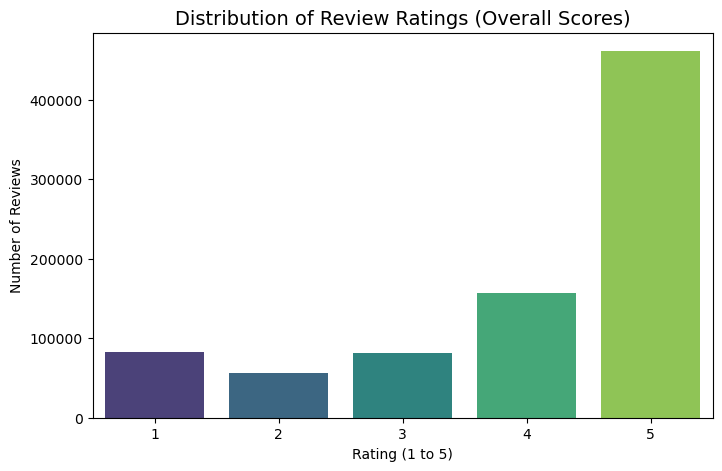

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='overall', data=train_1, palette='viridis')

plt.title('Distribution of Review Ratings (Overall Scores)', fontsize=14)
plt.xlabel('Rating (1 to 5)')
plt.ylabel('Number of Reviews')
plt.show()

# متعادل‌سازی داده‌ها (Class Balancing با Oversampling)

در داده‌های متنی معمولاً تعداد نمونه‌ها در هر کلاس (مثلاً نمره‌های ۱ تا ۵) برابر نیست.
این مسئله باعث می‌شود مدل شبکه‌ی عصبی در یادگیری به سمت کلاس‌های پرتعداد متمایل شود.
برای رفع این مشکل از Oversampling استفاده می‌کنیم.

In [22]:
import pandas as pd
from sklearn.utils import resample

# 1️⃣ ترکیب داده‌ها در یک DataFrame
train_df = pd.DataFrame({
    'text': X_train_clean,
    'label': Y_train
})

# 2️⃣ جدا کردن هر کلاس
dfs = [train_df[train_df['label'] == i] for i in sorted(train_df['label'].unique())]

# 3️⃣ پیدا کردن اندازه‌ی بزرگ‌ترین کلاس
max_len = max(len(d) for d in dfs)
print("بیشترین اندازه کلاس:", max_len)

# 4️⃣ Oversample همه کلاس‌ها تا اندازه‌ی بزرگ‌ترین کلاس
dfs_balanced = [
    resample(d, replace=True, n_samples=max_len, random_state=42)
    for d in dfs
]

# 5️⃣ ترکیب و Shuffle
train_balanced = pd.concat(dfs_balanced)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 6️⃣ خروجی نهایی
X_train_balanced = train_balanced['text'].tolist()
y_train_balanced = train_balanced['label'].tolist()

print(train_balanced['label'].value_counts())



بیشترین اندازه کلاس: 461440
label
1    461440
4    461440
3    461440
5    461440
2    461440
Name: count, dtype: int64
name


# توکن‌سازی و یکسان‌سازی طول جملات (Tokenization & Padding)

در این مرحله، هدف ما تبدیل داده‌های متنی به دنباله‌ای از اعداد است تا مدل شبکه عصبی بتواند با آن‌ها کار کند.


In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB_SIZE = 10000    # تعداد واژه‌هایی که نگه می‌داریم
MAX_SEQ_LEN = 50      # طول هر جمله بعد از padding

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_balanced)

X_train_seq = tokenizer.texts_to_sequences(X_train_balanced)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

In [17]:
from sklearn.model_selection import train_test_split

X_train_pad, X_val_pad, y_train, y_val = train_test_split( X_train_pad, y_train_balanced, test_size=0.25, random_state=42)

# تبدیل برچسب‌ها (Labels) به قالب عددی — One-Hot Encoding

مدل‌های شبکه عصبی معمولاً نمی‌توانند مستقیماً با برچسب‌های متنی یا عددی کار کنند.
برای مسائل چندکلاسه (مثل این پروژه که ۵ کلاس از امتیاز ۱ تا ۵ داریم) باید برچسب‌ها به شکل بردار دودویی (One-Hot) تبدیل شوند.

In [ ]:
from tensorflow.keras.utils import to_categorical
import numpy as np
y = np.array(y_train).astype(int)
y = y - 1
y_train_cat = to_categorical(y, num_classes=5)
y_v = np.array(y_val).astype(int)
y_v =y_v -  1
y_val_cat = to_categorical(y_v, num_classes=5)

# model 1

#  ساخت مدل پایه با Bidirectional LSTM

در این بخش یک مدل پایه‌ی بازگشتی برای تحلیل احساسات طراحی می‌کنیم.  
هدف این مدل، یادگیری روابط ترتیبی بین واژه‌ها در متن است. از لایه‌ی **Embedding** برای تبدیل هر واژه به برداری عددی استفاده می‌شود و سپس با یک **LSTM دوطرفه (Bidirectional)**، اطلاعات از دو جهت (جلو و عقب) استخراج می‌گردد.

### توضیحات معماری مدل:
- **Embedding Layer:** نگاشت هر واژه به یک بردار با ابعاد `128` (برای درک معنا).
- **Bidirectional LSTM:** با ۱۲۸ نورون، جهت درک توالی واژه‌ها از هر دو سمت جمله.
- **Dropout:** دو Dropout با مقادیر `0.4` و `0.3` برای جلوگیری از overfitting.
- **Dense Layer:** لایه‌ی Fully Connected با تابع فعال‌سازی `ReLU` و منظم‌سازی L2.
- **Output Layer:** لایه خروجی با ۵ نورون و تابع `softmax` برای طبقه‌بندی ۵‌کلاسه.

مدل با تابع هزینه‌ی **Categorical Crossentropy** و بهینه‌ساز **Adam** با نرخ یادگیری `1e-3` کامپایل می‌شود.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow import keras
import tensorflow as tf

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
embedding_dim = 128  # اندازه‌ی بردار هر واژه

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_SEQ_LEN),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(5, activation='softmax')])
model.compile(
    loss='categorical_crossentropy',optimizer=keras.optimizers.Adam(learning_rate=1e-3),metrics=['accuracy'])


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True,),ModelCheckpoint('best_review_model.keras', save_best_only=True)]

history = model.fit(X_train_pad, y_train_cat,epochs=30,batch_size=128,callbacks=callbacks,validation_data=(X_val_pad, y_val_cat),)


Epoch 1/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 214s 16ms/step - accuracy: 0.5837 - loss: 1.0159 - val_accuracy: 0.6555 - val_loss: 0.8827
Epoch 2/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 210s 16ms/step - accuracy: 0.6905 - loss: 0.8111 - val_accuracy: 0.7314 - val_loss: 0.7293
Epoch 3/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 212s 16ms/step - accuracy: 0.7625 - loss: 0.6489 - val_accuracy: 0.7771 - val_loss: 0.6206
Epoch 4/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 212s 16ms/step - accuracy: 0.8068 - loss: 0.5391 - val_accuracy: 0.8078 - val_loss: 0.5437
Epoch 5/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 211s 16ms/step - accuracy: 0.8360 - loss: 0.4657 - val_accuracy: 0.8283 - val_loss: 0.4990
Epoch 6/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 223s 16ms/step - accuracy: 0.8557 - loss: 0.4153 - val_accuracy: 0.8444 - val_loss: 0.4584
Epoch 7/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 211s 16ms/step - accuracy: 0.8709 - loss: 0.3764 - val_accuracy: 0.8516 - val_loss: 0.4456
Epoch 8/30
13519/13519 ━━━━━━━━━━━━━━━━━━━━ 211s 16ms/s

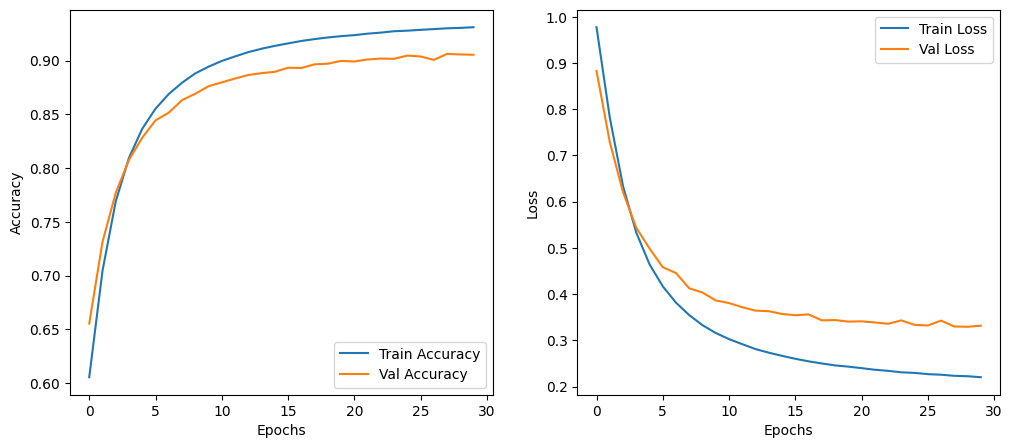

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [1]:
from tensorflow import keras

# مدل ذخیره‌شده رو از فایل بارگذاری می‌کنیم
model = keras.models.load_model('best_review_model.keras')

# بررسی ساختار مدل
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,730,129 (18.04 MB)

 Trainable params: 1,576,709 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,153,420 (12.03 MB)

In [47]:

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = np.argmax(model.predict(X_val_pad), axis=1)
y_true = np.argmax(y_val_cat, axis=1)
y_pred_proba = model.predict(X_val_pad, verbose=1)

print(classification_report(y_true, y_pred))


18025/18025 ━━━━━━━━━━━━━━━━━━━━ 297s 17ms/step
              precision    recall  f1-score   support

           0       0.25      0.09      0.13    115311
           1       0.22      0.01      0.02    115505
           2       0.23      0.12      0.16    114985
           3       0.23      0.15      0.18    115743
           4       0.21      0.73      0.33    115256

    accuracy                           0.22    576800
   macro avg       0.23      0.22      0.16    576800
weighted avg       0.23      0.22      0.16    576800



In [19]:
# ایندکس نمونه‌هایی که درست یا غلط پیش‌بینی شدن
correct_idx = np.where(y_pred == y_true)[0]
wrong_idx   = np.where(y_pred != y_true)[0]

print(f"✅ تعداد پیش‌بینی درست: {len(correct_idx)}")
print(f"❌ تعداد پیش‌بینی غلط: {len(wrong_idx)}")


✅ تعداد پیش‌بینی درست: 522412
❌ تعداد پیش‌بینی غلط: 54388


In [20]:
# تابع کمکی برای چاپ منظم
def show_examples(idxs, title):
    print(f"\n{'='*10} {title} {'='*10}")
    for i in idxs:
        print(f"\n📝 متن: {X_val_pad[i][:400]}...")  # نمایش ۴۰۰ کاراکتر اول
        print(f"🎯 درست: {y_true[i]} | 🔮 پیش‌بینی مدل: {y_pred[i]}")
        print("-"*60)

# انتخاب ۵ نمونه تصادفی از درست و غلط‌ها
np.random.seed(42)
correct_samples = np.random.choice(correct_idx, 5, replace=False)
wrong_samples   = np.random.choice(wrong_idx, 5, replace=False)

# نمایش
show_examples(correct_samples, "پیش‌بینی‌های صحیح")
show_examples(wrong_samples, "پیش‌بینی‌های غلط")



========== پیش‌بینی‌های صحیح ==========

📝 متن: [ 111   10   11   34   32  732 1788   14    6 3152    3  241    7   37
 2685    4   34    4  564 1734   30  214    2  114   19   20    4 1690
    5 1444    2 4166  123   81    9    2  100 1203    4   49    7   42
   66   51    6  135  667    3  144 1496]...
🎯 درست: 1 | 🔮 پیش‌بینی مدل: 1
------------------------------------------------------------

📝 متن: [  10    8    6  623   80   15   74 5157    4    7   11  407   38 1013
   19   79  928    2  558   26   19  269    7 1400 1144   32   28 1138
   56   78  250    8 1769  391    6  614 1480  653   42   28 3004    5
 9384  897   24   27    9   51    6  135]...
🎯 درست: 3 | 🔮 پیش‌بینی مدل: 3
------------------------------------------------------------

📝 متن: [5978    1   10    8    2  231  113 2890  104  386    1   22   19 3098
    2  113    2  762 7910    5  865    4    1   28 2251    3   34    7
   16   12  352  219  121 3703    5  419  316  506  113 1225    6  103
  509    6  171  112    

In [23]:
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
def decode_review(sequence):
    return ' '.join([reverse_word_index.get(i, '?') for i in sequence if i != 0])

for i in wrong_samples:
  sequence = X_val_pad[i]
  print(decode_review(sequence))
  print(" واقعی:", y_true[i], " پیش‌بینی:", y_pred[i])
  print("-"*80)



i bought s cat at best buy to compare with the cat i purchased with amazon to me it seemed like the cat was faster so im using the cat instead ill give the cat away to someone who needs one
 واقعی: 3  پیش‌بینی: 4
--------------------------------------------------------------------------------
similar to jaybird better quality in both sound and material and she has a chinese or korean accent the form factor on these bluetooth headphones are very similar to the expensive jaybird bluetooth headphones ive had them as well from a while back immediately as soon as they came out
 واقعی: 4  پیش‌بینی: 0
--------------------------------------------------------------------------------
i bought this camera in november and it worked fine however it didnt come with a cord to transfer the pictures to a computer i had to order that separately i thought it was nice that it uses regular aa batteries but they run out quickly now its april and
 واقعی: 0  پیش‌بینی: 1
---------------------------------------